# Prédiction des Ventes Walmart

## Sommaire
1. Importation et Vue d'ensemble
2. Analyse Exploratoire (EDA)
3. Préparation Machine Learning (Scikit-Learn)
4. Modèle Baseline : Régression Linéaire
5. Optimisation : Régression Ridge
6. Conclusion

## 1. Importation et Vue d'ensemble

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')


In [ ]:
#  Chargement des données
df = pd.read_csv('src/Walmart_Store_sales.csv')
print("Lignes initiales :", df.shape[0])
df.head()

Lignes initiales : 150


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,18-02-2011,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,25-03-2011,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,27-07-2012,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaN,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,28-05-2010,1644470.66,0.0,78.89,2.759,212.412888,7.092


In [3]:
print('\ntype de données \n')
print(df.info())


type de données 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         150 non-null    float64
 1   Date          132 non-null    object 
 2   Weekly_Sales  136 non-null    float64
 3   Holiday_Flag  138 non-null    float64
 4   Temperature   132 non-null    float64
 5   Fuel_Price    136 non-null    float64
 6   CPI           138 non-null    float64
 7   Unemployment  135 non-null    float64
dtypes: float64(7), object(1)
memory usage: 9.5+ KB
None


In [4]:
print(f'valeurs manquantes par colonnes : \n\n{df.isna().sum().sort_values(ascending=False)}')

valeurs manquantes par colonnes : 

Date            18
Temperature     18
Unemployment    15
Weekly_Sales    14
Fuel_Price      14
Holiday_Flag    12
CPI             12
Store            0
dtype: int64


In [5]:
print('\n données statistiques \n')
df.describe(include="all")



 données statistiques 



,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,150.000000,132,1.360000e+02,138.000000,132.000000,136.000000,138.000000,135.000000
unique,NaN,85,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,19-10-2012,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN
mean,9.866667,NaN,1.249536e+06,0.079710,61.398106,3.320853,179.898509,7.598430
std,6.231191,NaN,6.474630e+05,0.271831,18.378901,0.478149,40.274956,1.577173
min,1.000000,NaN,2.689290e+05,0.000000,18.790000,2.514000,126.111903,5.143000
25%,4.000000,NaN,6.050757e+05,0.000000,45.587500,2.852250,131.970831,6.597500
50%,9.000000,NaN,1.261424e+06,0.000000,62.985000,3.451000,197.908893,7.470000
75%,15.750000,NaN,1.806386e+06,0.000000,76.345000,3.706250,214.934616,8.150000


## Premier constat : 
### On est sur un dataset ultra petit.
### Il y a un fort taux de valeurs manquantes avec plus de 10% sur les 150 lignes initiales.
### Il va être nécessaire de supprimer les lignes sans target.
### Il va également être nécessaire de formater la colonne date au format datetime

In [6]:
# Suppression des lignes où la variable cible 'Weekly_Sales' est manquante
df = df.dropna(subset=['Weekly_Sales'])
print("Après suppression des NaN sur la cible :", df.shape[0])

Après suppression des NaN sur la cible : 136


In [7]:
# Formatage de la colonne Date 
# création de 4 nouvelles colonnes à partir de 'date'
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

# On peut maintenant supprimer la colonne Date originale
df = df.drop(columns=['Date'])

/tmp/ipykernel_959/1662293725.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


### Traitement des outliers par la règle des 3 sigmas

In [ ]:
# liste des colonnes pour lesquels 0.3% des extrèmes (considérés comme abbérantes) vont être supprimé
cols_outliers = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

for col in cols_outliers:
    mean = df[col].mean()
    std = df[col].std()
    
    # On ne garde que ce qui est dans l'intervalle [mean - 3*std, mean + 3*std]  ou '|' -> 'null'
    condition = (df[col] >= mean - 3 * std) & (df[col] <= mean + 3 * std) | (df[col].isna())
    df = df[condition]

## 2. Analyse Exploratoire (EDA)

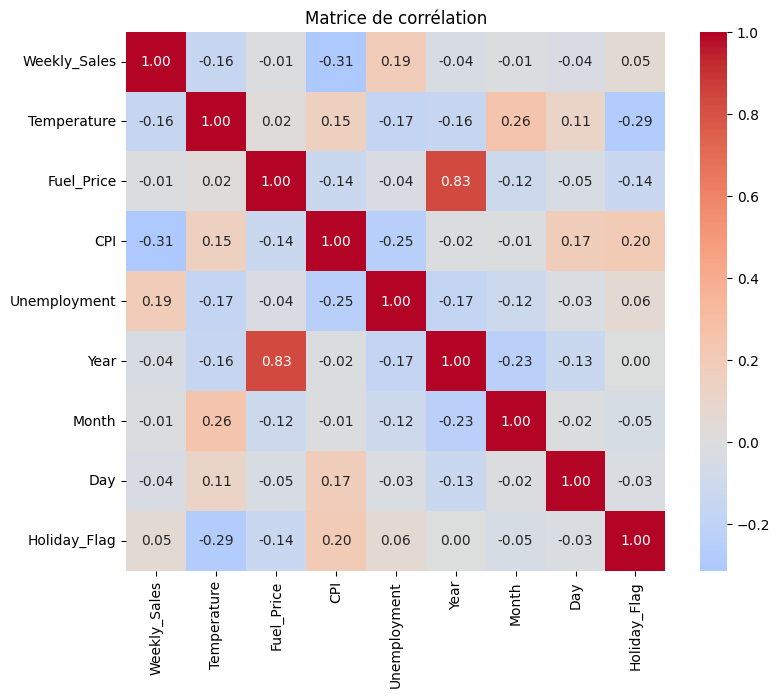

In [10]:

num_for_corr = ["Weekly_Sales","Temperature","Fuel_Price","CPI","Unemployment",
                "Year","Month","Day","Holiday_Flag"]
corr = df[num_for_corr].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matrice de corrélation")
plt.show()



### Les corrélations linéaires avec Weekly_Sales sont faibles dans l'ensemble.
### Le chômage ressort du lot ensuite on est sur du temporel avec sûrement des comportements saisonniers ou événementiels. 
### A noter une forte colinéarité entre Year et fuel_price indiquant une hausse continue sur la durée

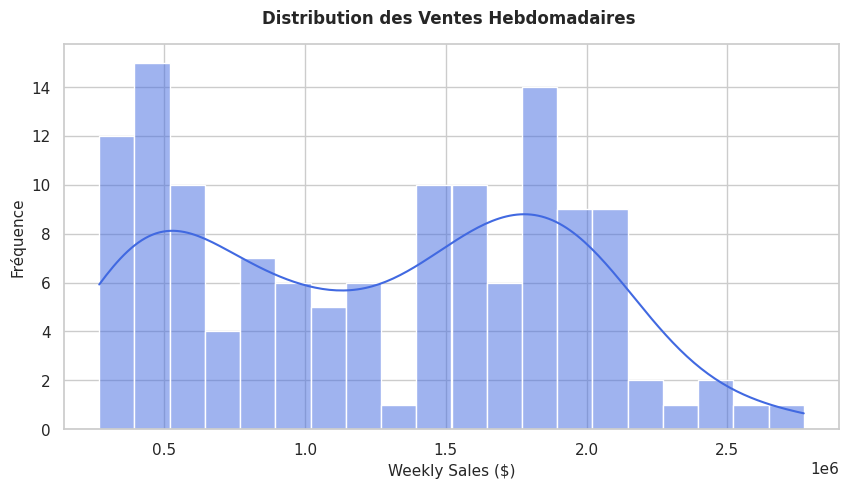

On distingue deux groupes : 
 - le premier entre 0.4M et 1.1M : activité 'standard'
 - le deuxième de 1.4M à 2.1M : période haute, probablement liée à des événements saisonniers ou promos


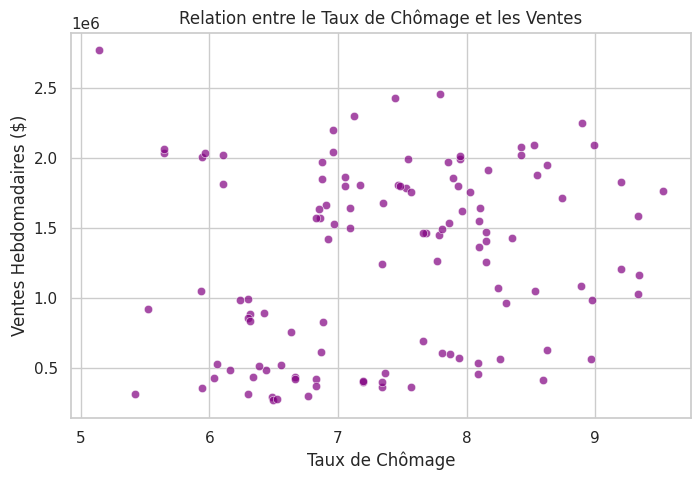

Il n'y a pas de lien linéaire clair entre le chômage et le volume des ventes (malgré une corrélation faible à 0.19).


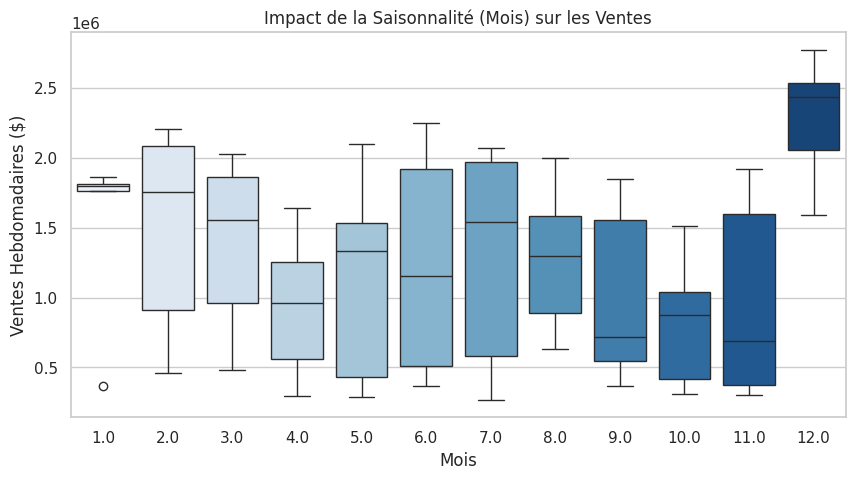

Les ventes sont dominées incontestablement par le mois de décembre, 
tandis que le reste de l'année oscille entre un premier trimestre bon, 
suivi d'un creux marqué en avril et d’un léger rebond estival en juillet,
 avant un déclin progressif jusqu'à décembre.


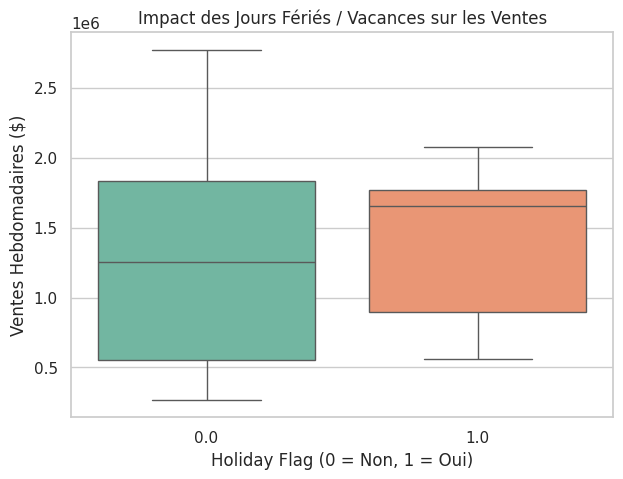

Avis contrasté : les jours fériés tirent la médiane vers le haut, 
mais ils ne captent pas la totalité des records de ventes (ex: Black Friday manquant ?).


In [ ]:
sns.set_theme(style="whitegrid")

# distribution de Weekly_Sales
plt.figure(figsize=(10, 5))
# On utilise kde=True pour voir si la distribution est normale
sns.histplot(data=df, x='Weekly_Sales', kde=True, color='royalblue', bins=20)
plt.title('Distribution des Ventes Hebdomadaires ', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Weekly Sales ($)', fontsize=11)
plt.ylabel('Fréquence', fontsize=11)
plt.show()

# Interprétation : La bimodalité suggère deux régimes de ventes différents dans nos données
print("On distingue deux groupes : \n - le premier entre 0.4M et 1.1M : activité 'standard'\n - le deuxième de 1.4M à 2.1M : période haute, probablement liée à des événements saisonniers ou promos")


#analyse du chômage
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Unemployment', y='Weekly_Sales', color='purple', alpha=0.7)
plt.title('Relation entre le Taux de Chômage et les Ventes')
plt.xlabel('Taux de Chômage')
plt.ylabel('Ventes Hebdomadaires ($)')
plt.show()


print("Il n'y a pas de lien linéaire clair entre le chômage et le volume des ventes (malgré une corrélation faible à 0.19).")


# Saisonnalité par mois 
plt.figure(figsize=(10, 5))

sns.boxplot(data=df, x='Month', y='Weekly_Sales', palette='Blues')
plt.title('Impact de la Saisonnalité (Mois) sur les Ventes')
plt.xlabel('Mois')
plt.ylabel('Ventes Hebdomadaires ($)')
plt.show()

# Observation : Décembre est une valeur aberrante positive évidente
print("Les ventes sont dominées incontestablement par le mois de décembre, \ntandis que le reste de l'année oscille entre un premier trimestre bon, \nsuivi d'un creux marqué en avril et d’un léger rebond estival en juillet,\n avant un déclin progressif jusqu'à décembre.")


# Impacts des jours fériés
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Holiday_Flag', y='Weekly_Sales', palette='Set2')
plt.title('Impact des Jours Fériés / Vacances sur les Ventes')
plt.xlabel('Holiday Flag (0 = Non, 1 = Oui)')
plt.ylabel('Ventes Hebdomadaires ($)')
plt.show()


print("Avis contrasté : les jours fériés tirent la médiane vers le haut, \nmais ils ne captent pas la totalité des records de ventes (ex: Black Friday manquant ?).")

### L'analyse démontre que les ventes sont fortement influencées par une saisonnalité marquée, avec un pic significatif en fin d'année. Par ailleurs, les périodes de jours fériés et de vacances entraînent une hausse globale du niveau des ventes ainsi qu'une plus grande stabilité des performances hebdomadaires.

## 3. Préparation Machine Learning (Scikit-Learn)
* Séparation en ensembles d'entraînement (80%) et de test (20%).
* Pipelines d'imputation, de standardisation et d'encodage (One-Hot).

In [40]:
# on sépare les données en features explicatives  et cible 
X = df.drop(columns=['Weekly_Sales'])
Y = df['Weekly_Sales']

# découpage classique en 80/20 pour garder un set de test indépendant
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


# on liste les colonnes selon leur nature pour appliquer des traitements différents
categorical_features = ['Store', 'Holiday_Flag']
numeric_features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'DayOfWeek']

# pipeline pour le numérique (Normalisation) : on remplit les trous par la médiane et on centre/réduit les valeurs 
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# pipeline pour le catégoriel : on remplit les vides par la valeur la plus fréquente puis on encode en one-hot (une classe -1 par colonne)
# on utilise drop='first' pour éviter la multicolinéarité qui pose problème en régression
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore')) # handle_unknown='ignore' remplace par 0 les valeurs catégorielles si une des classes rencontrées en test n'existe pas en train (plantage)
])

# merge des pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


# Application du préprocesseur sur le Train et le Test
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

## 4. Modèle Baseline : Régression Linéaire

In [82]:
# on entraîne notre modèle de régression linéaire sur les données déjà transformées par le pipeline
lr_model = LinearRegression()
lr_model.fit(X_train_preprocessed, Y_train)

# on génère les prédictions pour le train et le test pour vérifier la performance
Y_train_pred = lr_model.predict(X_train_preprocessed)
Y_test_pred = lr_model.predict(X_test_preprocessed)

# on affiche les scores pour voir si le modèle généralise bien
print("--- baseline : régression linéaire ---")
print(f"train r² : {r2_score(Y_train, Y_train_pred):.4f}")
print(f"test r²  : {r2_score(Y_test, Y_test_pred):.4f}")
print(f"test rmse: {np.sqrt(mean_squared_error(Y_test, Y_test_pred)):.2f}")
print(f"overfitting : {round(r2_score(Y_train, Y_train_pred)-r2_score(Y_test, Y_test_pred),2)*100}%")



# on récupère les noms des colonnes générées par le onehotencoder pour les associer aux coefficients
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
encoded_cat_features = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_features = numeric_features + encoded_cat_features

# on crée un tableau propre avec le nom de la feature et le poids associé dans le modèle
coef_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': lr_model.coef_
})


print("\nTop 10 des impacts directs sur les ventes dans l'ordre décroissant :")
print(round(coef_df.sort_values(by='Coefficient', ascending=False).head(10),0))

--- baseline : régression linéaire ---
train r² : 0.9777
test r²  : 0.8977
test rmse: 188477.53
overfitting : 8.0%

Top 10 des impacts directs sur les ventes dans l'ordre décroissant :
             Feature  Coefficient
11          Store_14     605226.0
20           Store_4     575156.0
18          Store_20     470172.0
10          Store_13     452900.0
8           Store_10     441918.0
17           Store_2     364779.0
5              Month      67412.0
26  Holiday_Flag_1.0      51506.0
2                CPI      48864.0
16          Store_19       2823.0


### L'analyse des coefficients révèle que l'identité du magasin est ce qui influence le plus les ventes, ce coté unique surpasse le calendrier et les données conjoncturelles (férié, chômage, prix de l'essence , température ...) .

## 5. Optimisation : Régression Ridge
* Recherche du meilleur hyperparamètre `alpha` via validation croisée (`GridSearchCV`).

In [86]:
ridge = Ridge()
# on teste différentes forces de régularisation (alpha)
params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}

# la validation croisée (cv=5) va tester chaque alpha pour trouver celui qui maximise le r²
grid_ridge = GridSearchCV(estimator=ridge, param_grid=params, cv=5, scoring='r2')
grid_ridge.fit(X_train_preprocessed, Y_train)

print(f"Meilleur hyperparamètre alpha trouvé : {grid_ridge.best_params_['alpha']}")

# on récupère le modèle optimal pour l'évaluer sur nos données
best_ridge = grid_ridge.best_estimator_
Y_test_pred_ridge = best_ridge.predict(X_test_preprocessed)

# on génère aussi les prédictions d'entraînement pour bien calculer l'overfitting du ridge
Y_train_pred_ridge = best_ridge.predict(X_train_preprocessed)

print(f"Ridge - Train R² : {grid_ridge.best_score_:.4f} (Moyenne CV)")
print(f"Ridge - Test R²  : {r2_score(Y_test, Y_test_pred_ridge):.4f}")
print(f"Ridge - Test RMSE: {np.sqrt(mean_squared_error(Y_test, Y_test_pred_ridge)):.2f}")

# calcul de l'overfitting spécifique au modèle ridge
overfitting_ridge = round(r2_score(Y_train, Y_train_pred_ridge) - r2_score(Y_test, Y_test_pred_ridge), 2) * 100
print(f"overfitting : {overfitting_ridge}%")

Meilleur hyperparamètre alpha trouvé : 0.01
Ridge - Train R² : 0.9474 (Moyenne CV)
Ridge - Test R²  : 0.8984
Ridge - Test RMSE: 187887.77
overfitting : 8.0%


## 6. Conclusion de l'analyse

Nous avons réussi à construire un modèle fiable (R² de 0.89) qui ne sur-apprend pas, capable de prédire les ventes hebdomadaires avec une bonne précision. 

Si l'on doit retenir une chose de cette analyse pour le business, c'est que **tous les leviers n'ont pas le même poids** :

L'immense majorité du chiffre d'affaires s'explique simplement par **l'identité du magasin**. Le facteur géographique et structurel surpasse de très loin les événements extérieurs. 

Cependant, on observe que **le calendrier agit comme un puissant amplificateur**. Décembre et les semaines de jours fériés sont des moments de bascule incontournables qui viennent booster ce volume de base. Enfin, le contexte économique local (comme l'indice des prix) apporte une dernière nuance à ces résultats.

**En une phrase :** L'adresse du magasin détermine le volume de croisière, le calendrier détermine les pics de charge.